# Entersoft A.E.: Financial Statement Analysis, 2014-2017

**Context.** Rebuild of a financial-statement analysis written for the University of West Attica course
*Analysis of Financial Statements* (Dept. of Tourism Management, 2nd semester, 2019-20). The original work compared pre-computed ratios year by year in a Word report.
This notebook recomputes every ratio from raw statement items, **audits the workbook inputs against Entersoft's published annual reports**, corrects what does not match,
and then analyses the verified numbers.

**Company.** Entersoft A.E. is an Athens-listed enterprise-software company (ERP, retail and e-invoicing software and services).
All figures are the **parent-company (standalone)** statements, in EUR.

**Questions.**
1. Do the coursework workbook's inputs match the published annual reports, and what changes when errors are corrected?
2. How did growth, profitability, liquidity, leverage and working-capital efficiency evolve over 2014-2017?
3. Does the original report's conclusion (best year 2014, worst year 2015) hold up on verified data?

In [1]:
import unicodedata, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
RAW  = ROOT / "data" / "raw" / "entersoft_financial_statements_2014_2017.xlsx"
REF  = ROOT / "data" / "reference"; REF.mkdir(parents=True, exist_ok=True)
FIG  = ROOT / "figures";  FIG.mkdir(exist_ok=True)
PROC = ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)
RES  = ROOT / "results";  RES.mkdir(exist_ok=True)

SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK, "xtick.color": INK2, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False, "font.size": 10,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left", "savefig.dpi": 200, "figure.dpi": 110,
})

## 1. Load the statements as transcribed in the coursework workbook

Items are located by their (Greek) row labels rather than by row number, so the loader fails loudly if the layout changes.

In [2]:
nfc = lambda s: unicodedata.normalize("NFC", str(s)).strip()
raw = pd.read_excel(RAW, sheet_name="Φύλλο 1", header=None)
labels = raw[0].map(nfc)

def row(prefix, nth=0):
    hits = labels[labels.str.startswith(nfc(prefix))].index
    if len(hits) <= nth: raise KeyError(f"row not found: {prefix}")
    return raw.loc[hits[nth], 1:4].astype(float).values

years = [int(pd.Timestamp(v).year) for v in raw.loc[labels[labels.str.startswith("ΛΟΓΑΡΙΑΣΜΟΙ Κ.Α.Χ.")].index[0], 1:4]]
items = {   # English name -> row label prefix in the workbook
    "sales": "Πωλήσεις", "cogs": "Κόστος Πωληθέντων", "other_income": "Άλλα/Λοιπά Έσοδα Εκμετάλλευσης",
    "opex": "Έξοδα Διάθεσης", "fin_expense": "Χρηματοοικονομικά Έξοδα", "fin_income": "Χρηματοοικονομικά Έσοδα",
    "other_expense": "Άλλα/Λοιπά Έξοδα Εκμετάλλευσης", "depreciation": "Αποσβέσεις", "ebt_reported": "Κέρδη/(Ζημιές) Προ Φόρων",
    "ppe": "Ιδιοχρησιμοποιούμενα", "inventory": "Αποθέματα", "receivables": "Εμπορικές Απαιτήσεις", "cash": "Ταμειακά Διαθέσιμα",
    "current_assets": "Κυκλοφορούν Ενεργητικό", "payables": "Εμπορικές Υποχρεώσεις", "st_debt": "Βραχυπρόθεσμες Δανειακές",
    "current_liabilities": "Σύνολο Βραχυπρόθεσμων", "equity": "Ίδια Κεφάλαια", "lt_liabilities": "Μακροπρόθεσμες Υποχρεώσεις",
    "total_assets": "Σύνολο Ιδίων Κεφαλαίων",
}
wb = pd.DataFrame({k: row(v) for k, v in items.items()}, index=years).T
wb.columns.name = "year"
wb.to_csv(PROC / "statements_workbook_as_transcribed.csv")
(wb / 1e6).round(3)

year,2014,2015,2016,2017
sales,7.051,6.987,8.008,9.006
cogs,2.176,2.564,2.857,3.424
other_income,0.105,0.050,0.066,0.327
opex,3.306,4.060,3.570,4.588
fin_expense,0.034,0.077,0.037,0.187
fin_income,0.032,0.057,0.034,0.017
other_expense,0.003,0.037,0.007,0.011
depreciation,0.532,0.448,0.521,0.558
ebt_reported,1.669,0.846,1.148,1.138
ppe,0.206,0.192,0.218,0.281


## 2. Internal checks on the workbook

(a) Does the balance sheet balance? (b) Do the workbook's own pre-computed ratios reproduce from its own inputs?

In [3]:
f = wb.T   # rows = years
bs_gap = f.total_assets - (f.equity + f.current_liabilities + f.lt_liabilities)
print("Balance-sheet identity gap (EUR):", bs_gap.round(0).to_dict()); assert (bs_gap.abs() <= 5).all()

mine = pd.DataFrame({
    "Gross margin": (f.sales - f.cogs) / f.sales, "Opex / sales": f.opex / f.sales, "Current ratio": f.current_assets / f.current_liabilities,
    "Total liabilities / equity": (f.current_liabilities + f.lt_liabilities) / f.equity,
    "Receivables days": f.receivables / f.sales * 365, "Payables days": f.payables / f.cogs * 365}).T
wbr = pd.DataFrame({
    "Gross margin": row("Μικτό Περιθώριο Κέρδους"), "Opex / sales": row("Έξοδα Διοίκησης - Λειτουργίας - Έρευνας/Πωλήσεις"),
    "Current ratio": row("Γενική Ρευστότητα"), "Total liabilities / equity": row("Ξένα/Ιδια Κεφάλαια"),
    "Receivables days": row("Κυκλοφοριακή Ταχύτητα Απαιτήσεων"), "Payables days": row("Κυκλοφοριακή Ταχύτητα Υποχρεώσεων")}, index=years).T
mine.columns.name = None; wbr.columns.name = None
chk = pd.concat([mine.stack(), wbr.stack()], axis=1, keys=["recomputed", "workbook"]); chk.index.names = ["ratio", "year"]
chk["matches"] = np.where((chk.recomputed - chk.workbook).abs() < 0.01 * chk.workbook.abs().clip(lower=1e-9) + 1e-6, "yes", "NO")
chk.to_csv(RES / "workbook_ratio_check.csv")
print(f"{(chk.matches == 'yes').sum()} of {len(chk)} workbook ratios reproduce from the workbook's own inputs")
chk[chk.matches != "yes"].round(3)

Balance-sheet identity gap (EUR): {2014: 1.0, 2015: 0.0, 2016: -1.0, 2017: 0.0}
23 of 24 workbook ratios reproduce from the workbook's own inputs


,,recomputed,workbook,matches
ratio,year,,,
Receivables days,2014,218.039,0.0,NO


The workbook is internally consistent (the balance sheet balances, 23 of 24 ratios follow from its inputs; the exception is **2014 receivables days, shown as 0 instead of about 218**, because the formula had no prior-year input).
But **internal consistency does not prove the inputs are right**. The next step checks them against the source.

## 3. Audit against the published annual reports

The parent-company ("Company") statements were read from Entersoft's published annual financial reports (FY2015 report for 2014-2015, FY2016 report for 2015-2016, FY2017 report for 2016-2017; Athens Exchange / Euronext Athens filings) and entered below with their source pages.
Operating expenses are the sum of selling, administrative and research & development expenses.

In [4]:
# Official parent-company figures (EUR), read from the annual reports. Sources: FY2015 report p.12-13,15 (2014, 2015);
# FY2016 report p.11-12,14 (2015, 2016); FY2017 report p.16-17,19 (2016, 2017).
official_pl = pd.DataFrame({
    #            2014       2015       2016       2017
    "sales":        [7051344, 6986768, 8008120, 9005941],
    "cogs":         [2176063, 2563888, 2856707, 3423834],
    "other_income": [ 104543,   49755,   65531,  326944],
    "selling":      [1414779, 1516680, 1310432, 1403270],
    "admin":        [ 987248, 1012070, 1036002, 1428767],
    "rnd":          [ 903830, 1041016, 1713105, 1757576],
    "other_expense":[   2728,   37452,    6549,   10684],
    "operating_result_reported": [1671177, 865416, 1150855, 1308754],
    "fin_income":   [  32477,   56934,   33855,   16924],
    "fin_expense":  [  34202,   76732,   36628,  187251],
    "ebt_reported": [1669452,  845619, 1148083, 1138429],
    "depreciation": [ 448007,  531909,  521381,  558237],
}, index=years).T.astype(float)
official_bs = pd.DataFrame({
    "ppe":               [ 206284,  192107,  217827,  281087],
    "receivables":       [4212249, 3779848, 4469509, 5423598],
    "cash":              [ 683740, 1243691,  857211, 2321983],
    "current_assets":    [6879217, 6779702, 6407814, 8808658],
    "payables":          [ 116029,  393791,  128396,   62671],
    "st_debt":           [      0,  179253,  202253, 1435127],
    "current_liabilities":[1773398, 1865939, 1428790, 2599160],
    "equity":            [7211231, 8808737, 8891784, 9513718],
    "lt_liabilities":    [1441456,  191212,  139010,  341688],
    "total_assets":      [10426086,10865888,10459583,12454566],
}, index=years).T.astype(float)
official = pd.concat([official_pl, official_bs])
official.loc["opex"] = official.loc[["selling", "admin", "rnd"]].sum()
official.to_csv(REF / "annual_report_parent_company_figures.csv")

comparable = [k for k in wb.index if k in official.index and k != "inventory"]
diff = (wb.loc[comparable] - official.loc[comparable])
errors = diff.stack(); errors = errors[errors.abs() > 0.5].rename("workbook_minus_report").to_frame()
errors["workbook"] = [wb.loc[i, y] for i, y in errors.index]; errors["annual_report"] = [official.loc[i, y] for i, y in errors.index]
errors.index.names = ["item", "year"]; errors.to_csv(RES / "workbook_vs_annual_report_errors.csv")
print(f"Items compared: {len(comparable)} x {len(years)} years = {len(comparable) * len(years)} values; mismatches: {len(errors)}")
errors.astype(int)

Items compared: 19 x 4 years = 76 values; mismatches: 5


workbook_minus_report  workbook  annual_report
item         year                                                
opex         2015                 489773   4059539        3569766
             2016                -489773   3569766        4059539
             2017                  -2000   4587613        4589613
depreciation 2014                  83902    531909         448007
             2015                 -83902    448007         531909

**Finding 1: 5 of 76 inputs are wrong; everything else matches the annual reports exactly.**
- **Operating expenses 2015 and 2016 are transposed** (EUR 4,059,539 sits in the 2015 column but is the 2016 figure; EUR 3,569,766 sits in 2016 but is 2015). The two errors are exactly EUR 489,773 apart.
- **Operating expenses 2017** carry a EUR 2,000 typo (4,587,613 instead of 4,589,613).
- **Depreciation 2014 and 2015 are transposed** (531,909 vs 448,007).

All sales, cost of sales, other income, financial items, **reported profit before tax**, and every balance-sheet line (assets, receivables, cash, liabilities, equity) match to the euro.
Everything derived from operating expenses or depreciation (opex/sales, operating profit, EBITDA, interest cover) was therefore wrong for 2015-2017 in the workbook.

In [5]:
fin = wb.copy()
for item, yr in errors.index: fin.loc[item, yr] = official.loc[item, yr]      # replace only the mismatched cells
fin.to_csv(PROC / "statements_corrected.csv")

def rebuild(statements):
    s = statements.T
    ebit = s.sales - s.cogs - s.opex + s.other_income - s.other_expense
    return pd.DataFrame({"ebit": ebit, "ebt_rebuilt": ebit + s.fin_income - s.fin_expense, "ebt_reported": s.ebt_reported})
before, after = rebuild(wb), rebuild(fin)
recon = pd.DataFrame({"gap_before_correction": before.ebt_reported - before.ebt_rebuilt, "gap_after_correction": after.ebt_reported - after.ebt_rebuilt})
recon.to_csv(RES / "profit_reconciliation.csv")
recon.round(0)

,gap_before_correction,gap_after_correction
year,,
2014,-62.0,-62.0
2015,489773.0,0.0
2016,-489773.0,0.0
2017,-1998.0,2.0


**Reconciliation test.** Rebuilding profit before tax from the line items, the workbook as transcribed misses the reported figure by +EUR 489,773 (2015), -EUR 489,773 (2016) and -EUR 1,998 (2017): the fingerprint of the transpositions and the typo.
After correction the items reconcile to reported profit within **EUR 62** (a rounding inconsistency in the company's own 2014 statement), so the corrected statements are internally consistent *and* match the source.
This reconciliation was how the errors were first detected; the annual reports then confirmed the cause.

In [6]:
inc = pd.DataFrame(index=years)
s = fin.T
inc["sales"] = s.sales
inc["gross_profit"] = s.sales - s.cogs
inc["ebit"] = after.ebit
inc["ebitda"] = inc.ebit + s.depreciation
inc["ebt_reported"] = s.ebt_reported
# the company's own EBITDA line (operating result + depreciation) as a cross-check of the 'depreciation sits inside opex' assumption
report_ebitda = pd.Series([2199184, 1397325, 1672236, 1866991], index=years)
chk_ebitda = pd.DataFrame({"computed": inc.ebitda.round(0), "reported_in_annual_report": report_ebitda}); chk_ebitda["diff"] = chk_ebitda.computed - chk_ebitda.reported_in_annual_report
chk_ebitda

,computed,reported_in_annual_report,diff
2014,2119246.0,2199184,-79938.0
2015,1397326.0,1397325,1.0
2016,1672237.0,1672236,1.0
2017,1866991.0,1866991,0.0


The EBITDA assumption holds for 2015-2017 (computed EBITDA = operating result + depreciation matches the company's own summary line to within EUR 2, so depreciation is included in the functional expense lines).
For 2014 the company's summary line is about EUR 80,000 above operating result + depreciation (cash-flow statement supports depreciation of 448,007), which looks like a typo in the 2014 comparative; the computed figure is used.

## 4. Ratio analysis (verified data)

Year-end balances (no 2013 balance sheet is available for averages), 365 days, pre-tax profit measures (tax and net profit are not in the transcribed dataset, although the reports contain them).

In [7]:
r = pd.DataFrame(index=years)
prev_sales = pd.Series(s.sales.shift(1)); prev_sales.loc[2014] = s.sales.loc[2014] - row("Μεταβολή Πωλήσεων")[0]   # 2013 sales implied by the workbook's reported change
r["Sales growth"]            = s.sales / prev_sales - 1
r["Gross margin"]            = inc.gross_profit / s.sales
r["Opex / sales"]            = s.opex / s.sales
r["EBIT margin"]             = inc.ebit / s.sales
r["EBITDA margin"]           = inc.ebitda / s.sales
r["EBT margin"]              = s.ebt_reported / s.sales
r["Return on equity, pre-tax"] = s.ebt_reported / s.equity
r["Return on assets, pre-tax"] = s.ebt_reported / s.total_assets
r["Current ratio"]           = s.current_assets / s.current_liabilities
r["Cash ratio"]              = s.cash / s.current_liabilities
r["Working capital (EUR m)"] = (s.current_assets - s.current_liabilities) / 1e6
r["Total liabilities / equity"] = (s.current_liabilities + s.lt_liabilities) / s.equity
r["Equity / total assets"]   = s.equity / s.total_assets
r["Short-term borrowing (EUR m)"] = s.st_debt / 1e6
r["Interest cover (EBIT / financial expense)"] = inc.ebit / s.fin_expense
r["Receivables days"]        = s.receivables / s.sales * 365
r["Receivables days, ex-VAT (24%)"] = s.receivables / (s.sales * 1.24) * 365
r["Payables days"]           = s.payables / s.cogs * 365
r["Receivables / sales"]     = s.receivables / s.sales
ratios = r.T; ratios.to_csv(RES / "ratios.csv")
cagr = lambda a, b: (b / a) ** (1 / 3) - 1
cagr_sales, cagr_opex, cagr_cogs = cagr(s.sales[2014], s.sales[2017]), cagr(s.opex[2014], s.opex[2017]), cagr(s.cogs[2014], s.cogs[2017])
yoy = pd.DataFrame({"sales": s.sales.pct_change(), "cogs": s.cogs.pct_change(), "opex": s.opex.pct_change(), "ebit": inc.ebit.pct_change()}).loc[2015:]
print(f"CAGR 2014-2017: sales {cagr_sales:.1%} | cost of sales {cagr_cogs:.1%} | opex {cagr_opex:.1%}")
print("Year-on-year change:"); print((yoy * 100).round(1))
pct_rows = ["Sales growth","Gross margin","Opex / sales","EBIT margin","EBITDA margin","EBT margin","Return on equity, pre-tax","Return on assets, pre-tax","Equity / total assets","Receivables / sales"]
show = ratios.copy()
for k in show.index: show.loc[k] = show.loc[k] * 100 if k in pct_rows else show.loc[k]
show.round(1).assign(unit=["%" if k in pct_rows else ("x" if ("ratio" in k.lower() or "/" in k or "cover" in k.lower()) else "") for k in show.index])

CAGR 2014-2017: sales 8.5% | cost of sales 16.3% | opex 11.6%
Year-on-year change:
      sales  cogs  opex  ebit
2015   -0.9  17.8   8.0 -48.2
2016   14.6  11.4  13.7  33.0
2017   12.5  19.9  13.1  13.7


,2014,2015,2016,2017,unit
Sales growth,13.4,-0.9,14.6,12.5,%
Gross margin,69.1,63.3,64.3,62.0,%
Opex / sales,46.9,51.1,50.7,51.0,%
EBIT margin,23.7,12.4,14.4,14.5,%
EBITDA margin,30.1,20.0,20.9,20.7,%
EBT margin,23.7,12.1,14.3,12.6,%
"Return on equity, pre-tax",23.2,9.6,12.9,12.0,%
"Return on assets, pre-tax",16.0,7.8,11.0,9.1,%
Current ratio,3.9,3.6,4.5,3.4,x
Cash ratio,0.4,0.7,0.6,0.9,x


In [8]:
# What did the errors do to the headline ratios? (workbook as transcribed vs corrected)
w = wb.T
impact = pd.DataFrame({
    "Opex / sales: workbook":  w.opex / w.sales,   "Opex / sales: corrected": s.opex / s.sales,
    "EBIT margin: workbook":   before.ebit / w.sales, "EBIT margin: corrected": after.ebit / s.sales,
    "EBITDA margin: workbook": (before.ebit + w.depreciation) / w.sales, "EBITDA margin: corrected": inc.ebitda / s.sales,
    "Interest cover: workbook": before.ebit / w.fin_expense, "Interest cover: corrected": inc.ebit / s.fin_expense}).T
impact.to_csv(RES / "impact_of_corrections.csv")
impact.round(3)

,2014,2015,2016,2017
Opex / sales: workbook,0.469,0.581,0.446,0.509
Opex / sales: corrected,0.469,0.511,0.507,0.510
EBIT margin: workbook,0.237,0.054,0.205,0.146
EBIT margin: corrected,0.237,0.124,0.144,0.145
EBITDA margin: workbook,0.312,0.118,0.270,0.208
EBITDA margin: corrected,0.301,0.200,0.209,0.207
Interest cover: workbook,48.864,4.896,44.792,7.000
Interest cover: corrected,48.864,11.278,31.420,6.989


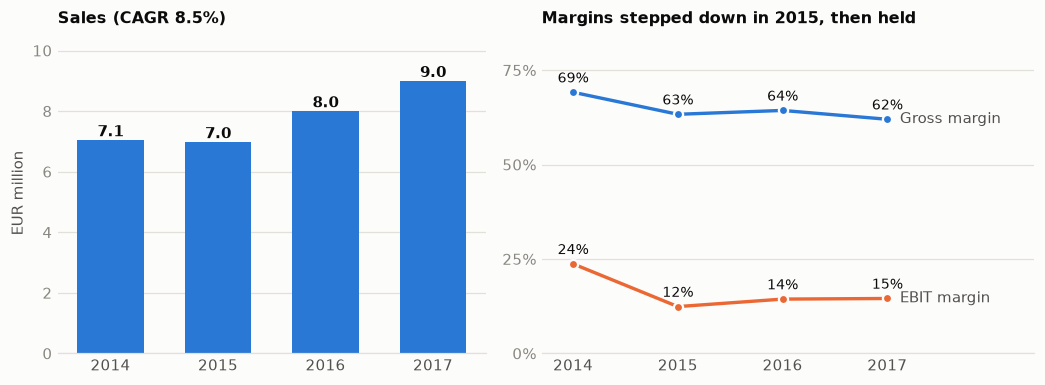

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6), gridspec_kw={"width_ratios": [1, 1.15]})
ax = axes[0]
ax.bar(years, s.sales / 1e6, width=0.62, color=BLUE, zorder=2)
for yr, v in zip(years, s.sales / 1e6): ax.text(yr, v + 0.12, f"{v:.1f}", ha="center", fontsize=9.5, fontweight="bold")
ax.set_xticks(years); ax.set_ylim(0, 10.6); ax.set_ylabel("EUR million"); ax.tick_params(length=0); ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_title(f"Sales (CAGR {cagr_sales:.1%})", fontsize=10.5)
ax = axes[1]
for col, color, name in [("Gross margin", BLUE, "Gross margin"), ("EBIT margin", ORANGE, "EBIT margin")]:
    ax.plot(years, r[col] * 100, color=color, lw=2.2, marker="o", ms=6, mec=SURFACE, mew=1.5, zorder=3)
    for yr, v in zip(years, r[col] * 100): ax.text(yr, v + 2.6, f"{v:.0f}%", ha="center", fontsize=9, color=INK)
    ax.text(2017.12, r[col].iloc[-1] * 100, name, va="center", fontsize=9.5, color=INK2)
ax.set_xticks(years); ax.set_xlim(2013.7, 2018.4); ax.set_ylim(0, 85); ax.set_yticks([0, 25, 50, 75]); ax.set_yticklabels(["0%", "25%", "50%", "75%"])
ax.yaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True); ax.tick_params(length=0); ax.spines["left"].set_visible(False)
ax.set_title("Margins stepped down in 2015, then held", fontsize=10.5)
fig.tight_layout(); fig.savefig(FIG / "fig1_growth_and_margins.png"); plt.show()

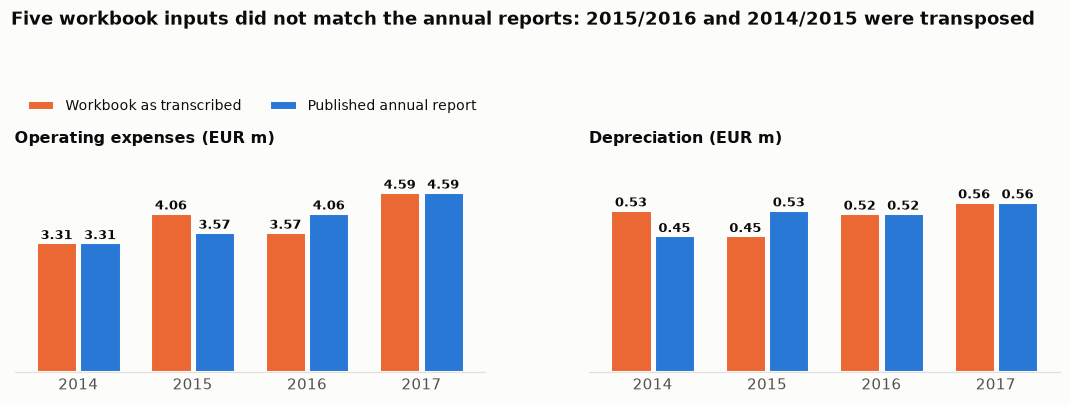

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9.8, 3.7))
def pair(ax, title, a, b, ylim, fmt="{:.2f}"):
    x = np.arange(len(years)); w_ = 0.36
    b1 = ax.bar(x - w_/2 - 0.01, a / 1e6, w_, color=ORANGE, edgecolor=SURFACE, linewidth=2, label="Workbook as transcribed")
    b2 = ax.bar(x + w_/2 + 0.01, b / 1e6, w_, color=BLUE, edgecolor=SURFACE, linewidth=2, label="Published annual report")
    for bars in (b1, b2):
        for bar in bars: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + ylim * 0.015, fmt.format(bar.get_height()), ha="center", fontsize=8.5, fontweight="bold")
    ax.set_xticks(x, years); ax.set_ylim(0, ylim); ax.set_yticks([]); ax.spines["left"].set_visible(False); ax.tick_params(length=0); ax.set_title(title, fontsize=10.5)
pair(axes[0], "Operating expenses (EUR m)", wb.loc["opex"], official.loc["opex"], 5.6)
pair(axes[1], "Depreciation (EUR m)", wb.loc["depreciation"], official.loc["depreciation"], 0.72)
axes[0].legend(frameon=False, loc="lower left", bbox_to_anchor=(0, 1.12), ncol=2, fontsize=9)
fig.suptitle("Five workbook inputs did not match the annual reports: 2015/2016 and 2014/2015 were transposed", x=0.012, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93)); fig.savefig(FIG / "fig2_workbook_vs_annual_report.png"); plt.show()

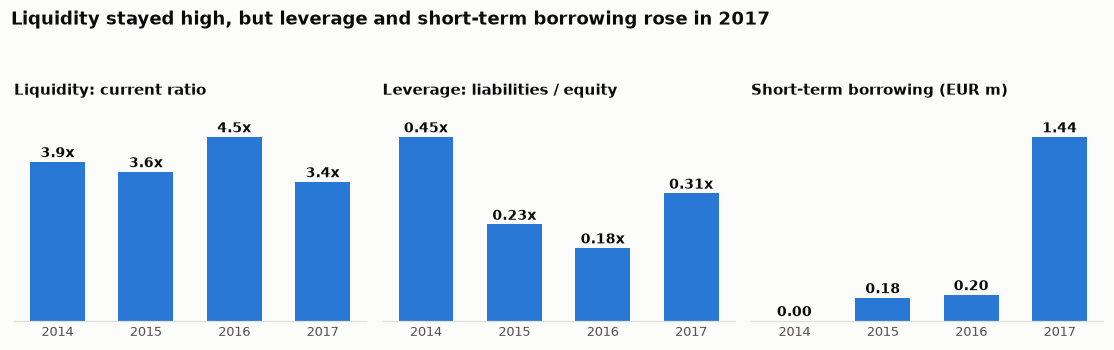

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.2))
spec = [(r["Current ratio"], "{:.1f}x", "Liquidity: current ratio"),
        (r["Total liabilities / equity"], "{:.2f}x", "Leverage: liabilities / equity"),
        (r["Short-term borrowing (EUR m)"], "{:.2f}", "Short-term borrowing (EUR m)")]
for ax, (ser, fmt, title) in zip(axes, spec):
    ax.bar(years, ser.values, width=0.62, color=BLUE, zorder=2)
    for yr, v in zip(years, ser.values): ax.text(yr, v + ser.max() * 0.025, fmt.format(v), ha="center", fontsize=9, fontweight="bold")
    ax.set_xticks(years); ax.tick_params(axis="x", labelsize=8.5); ax.set_ylim(0, ser.max() * 1.18)
    ax.set_yticks([]); ax.spines["left"].set_visible(False); ax.tick_params(length=0); ax.set_title(title, fontsize=10)
fig.suptitle("Liquidity stayed high, but leverage and short-term borrowing rose in 2017", x=0.012, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92)); fig.savefig(FIG / "fig3_liquidity_leverage.png"); plt.show()

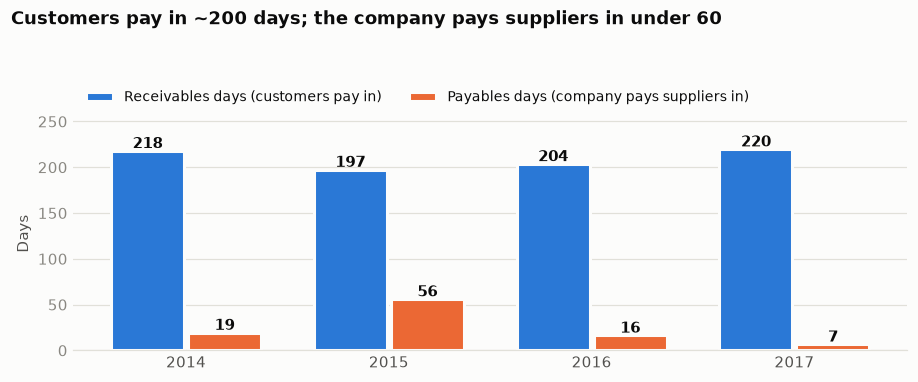

In [12]:
fig, ax = plt.subplots(figsize=(8.4, 3.5)); x = np.arange(len(years)); w_ = 0.36
b1 = ax.bar(x - w_/2 - 0.01, r["Receivables days"], w_, color=BLUE, edgecolor=SURFACE, linewidth=2, label="Receivables days (customers pay in)")
b2 = ax.bar(x + w_/2 + 0.01, r["Payables days"], w_, color=ORANGE, edgecolor=SURFACE, linewidth=2, label="Payables days (company pays suppliers in)")
for bars in (b1, b2):
    for b in bars: ax.text(b.get_x() + b.get_width()/2, b.get_height() + 3, f"{b.get_height():.0f}", ha="center", fontsize=9.5, fontweight="bold")
ax.set_xticks(x, years); ax.set_ylim(0, 255); ax.set_ylabel("Days"); ax.tick_params(length=0); ax.spines["left"].set_visible(False)
ax.yaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True); ax.legend(frameon=False, loc="lower left", fontsize=9, ncol=2, bbox_to_anchor=(0, 1.0))
fig.suptitle("Customers pay in ~200 days; the company pays suppliers in under 60", x=0.012, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.92)); fig.savefig(FIG / "fig4_working_capital.png"); plt.show()

## 5. Does the original report's conclusion hold?

The original report ranked the years **2014 (best) > 2016 > 2017 > 2015 (worst)**, based on reported profit before tax and the pre-computed ratios.

In [13]:
rank = pd.DataFrame({"EBT (EUR m)": s.ebt_reported / 1e6, "EBIT margin": r["EBIT margin"], "EBITDA margin": r["EBITDA margin"],
                     "Rank by EBT": s.ebt_reported.rank(ascending=False).astype(int),
                     "Rank by EBIT margin": r["EBIT margin"].rank(ascending=False).astype(int)})
rank.round(3)

,EBT (EUR m),EBIT margin,EBITDA margin,Rank by EBT,Rank by EBIT margin
2014,1.669,0.237,0.301,1,1
2015,0.846,0.124,0.200,4,4
2016,1.148,0.144,0.209,2,3
2017,1.138,0.145,0.207,3,2


## 6. Conclusions and limitations

**1. The inputs needed auditing: 5 of 76 values were wrong, with a large effect on the conclusions.** Operating expenses for 2015 and 2016 were transposed, depreciation for 2014 and 2015 was transposed, and 2017 operating expenses carried a EUR 2,000 typo (see section 3).
Sales, cost of sales, reported profit before tax and every balance-sheet line were correct, so the original ranking of years (based on profit before tax) is unaffected, but every opex- or depreciation-based ratio was distorted.
For example, the workbook put the 2015 EBIT margin at 5.4% and the 2016 margin at 20.5%; the verified figures are **12.4% and 14.4%**. Opex/sales was shown as 58.1% (2015) and 44.6% (2016); the verified figures are 51.1% and 50.7%.

**2. Profitability stepped down in 2015, then held.** Sales fell 0.9% in 2015 while cost of sales rose 17.8% and operating expenses 8.0%, so the gross margin dropped from **69.1% to 63.3%** and the EBIT margin from **23.7% to 12.4%**.
Since then the margin has been stable (14.4% in 2016, 14.5% in 2017) while sales grew 14.6% and 12.5%. Over 2014-2017 sales grew at 8.5% a year, cost of sales at 16.3% and operating expenses at 11.6%: growth has been bought with cost of sales, and the gross margin slid further to 62.0% in 2017.

**3. 2017: more sales, no more profit.** Profit before tax was flat (EUR 1.14m vs 1.15m) despite 12.5% sales growth, because financial expenses rose five-fold to EUR 187k as short-term borrowing went from EUR 0.2m to **EUR 1.4m**.
Interest cover fell to **7.0x** (from 31.4x in 2016). Still comfortable, but it is the one balance-sheet trend worth watching.

**4. Very strong liquidity and solvency.** Current ratio 3.4-4.5x, cash ratio up from 0.4x to 0.9x, equity funding 69-85% of assets, total liabilities only 0.18-0.45x equity.

**5. Working capital is the weak spot.** Trade receivables equal **54-60% of annual sales**, about 200-220 days of sales (**about 160-177 days once VAT at 24% is stripped out** of receivables), against 7-56 days of supplier credit.
Customers, not suppliers, finance this business's growth.

**6. Does the original conclusion hold? Yes on the ranking, with a nuance.** Ranked by profit before tax the order is 2014 > 2016 > 2017 > 2015, exactly as the original report concluded.
By EBIT margin, 2016 (14.4%) and 2017 (14.5%) are effectively tied, so their relative order is not meaningful; 2014 is clearly best and 2015 clearly worst.

**How the errors were found (method).** (a) The income statement was rebuilt from its line items; the result missed reported profit by +EUR 489,773 in 2015 and -EUR 489,773 in 2016, which pointed at transposed inputs; (b) the figures were then checked against Entersoft's published annual reports, which confirmed the cause and exposed the other three errors; (c) after correction the statements reconcile to reported profit within EUR 2 (2015-2017).

**Limitations.** Parent-company (standalone) statements only, not the consolidated group, whose figures differ (e.g. 2016 group sales EUR 10.7m vs 8.0m parent). Year-end balances only (no averages), pre-tax profit only (tax and net profit are in the reports but not in the transcribed dataset),
four years of data, one company and no peer benchmark. Official figures were entered by hand from the annual reports and cross-checked by the balance-sheet identity, the profit reconciliation and the company's own EBITDA line (2014 summary line differs by about EUR 80,000, apparently a typo in that comparative).

**Next steps.** Add the tax line and net profit, extend to 2018-2023, compare with listed Greek software peers, and add a cash-flow view.

In [14]:
summary = {
    "years": years, "cagr_sales": float(cagr_sales), "cagr_opex": float(cagr_opex), "cagr_cogs": float(cagr_cogs),
    "ratios": {k: [float(v) for v in ratios.loc[k].values] for k in ratios.index},
    "income": {k: [float(v) for v in inc[k].values] for k in ["sales", "gross_profit", "ebit", "ebitda", "ebt_reported"]},
    "errors_found": [{"item": i, "year": int(y), "workbook": float(v.workbook), "annual_report": float(v.annual_report)} for (i, y), v in errors.iterrows()],
    "values_compared": len(comparable) * len(years), "workbook_ratios_reproduced": int((chk.matches == "yes").sum()), "workbook_ratios_total": int(len(chk)),
    "gap_before": {int(k): float(v) for k, v in recon.gap_before_correction.items()}, "gap_after": {int(k): float(v) for k, v in recon.gap_after_correction.items()},
    "rank_by_ebt": rank["Rank by EBT"].to_dict(), "rank_by_ebit_margin": rank["Rank by EBIT margin"].to_dict(),
}
(RES / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8"); print("saved")

saved
